# Exploring the data

This notebook accompanies Chapter 2 of the manual
(`docs/02_the_data.md`). The chapter gives the orientation; here we actually
open the files and look at the numbers.

We answer four questions:

1. What is inside a dataset file, and how do we look at it?
2. What do raw power traces look like?
3. How different are the datasets from each other (scale and noise)?
4. At which time samples does the key leak? (the SNR)

Figures produced (shown in the chapters):
`outputs/figures/02_single_trace.png`, `02_traces_overview.png`,
`02_stats_table.png`, `02_snr_curves.png`.

In [1]:
# Note: no `matplotlib.use("Agg")` here — plain `python` runs fall back to a
# headless backend automatically, and the Jupyter kernel uses the inline
# backend, so the same code saves PNGs *and* displays figures in notebooks.
import matplotlib.pyplot as plt
import numpy as np

from feature_emergence.config import DATA_DIR, OUTPUTS_DIR
from feature_emergence.utils import load_dataset, snr_fast

out = OUTPUTS_DIR / "figures"
out.mkdir(parents=True, exist_ok=True)

## 1. What is inside a dataset file?

Each dataset is a single **`.h5` file** — an *HDF5* file. HDF5 (Hierarchical
Data Format) is a container for large numerical arrays: inside, the data is
organized like a filesystem, with *groups* (folders) and *datasets*
(arrays). You cannot open it in a text editor; you explore it with a
library, here `h5py`.

Let's open the CHES_CTF file and print its full structure:

In [2]:
import h5py

CHES_FILE = DATA_DIR / "ches_ctf" / "ches_ctf_nopoi_window_20.h5"

with h5py.File(CHES_FILE, "r") as f:
    def show(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"{name:40s} shape={str(obj.shape):15s} dtype={obj.dtype}")
    f.visititems(show)

Attack_traces/metadata                   shape=(10000,)        dtype=[('plaintext', 'u1', (16,)), ('ciphertext', 'u1', (16,)), ('key', 'u1', (16,))]
Attack_traces/traces                     shape=(10000, 15000)  dtype=float16
Profiling_traces/metadata                shape=(30000,)        dtype=[('plaintext', '<f8', (16,)), ('ciphertext', '<f8', (16,)), ('key', '<f8', (16,))]
Profiling_traces/traces                  shape=(30000, 15000)  dtype=float16


Two groups — `Profiling_traces` and `Attack_traces` — each with two arrays:

- `traces`: one power trace per row (thousands of time samples per row).
- `metadata`: one record per trace with the cryptographic values that
  produced it (plaintext, key, and ciphertext here).

Let's read the metadata of a single attack trace — record number 0:

In [3]:
with h5py.File(CHES_FILE, "r") as f:
    record = f["Attack_traces/metadata"][0]

print("plaintext :", bytes(record["plaintext"]).hex())
print("key       :", bytes(record["key"]).hex())
print("ciphertext:", bytes(record["ciphertext"]).hex())

plaintext : c549dd73446310a073b9f9c6bdc7e66d
key       : 175cf2997a8583413c77dfac7e6c59d8
ciphertext: e70e50e7a0829e5f6691ac64dde13056


This is one real AES-128 encryption: the device encrypted exactly this
plaintext with exactly this key and produced exactly this ciphertext (you
can verify it with any AES calculator). While it did so, an instrument
recorded the power trace stored in the same row of `traces`. That pairing —
*the crypto values* plus *the physical measurement* — is the whole dataset.

## 2. Loading the datasets with the package loaders

Opening files by hand works, but the package loaders hide the format
differences between datasets (dtypes, label computation, leakage models) and
give us trace arrays plus leakage labels directly.

To keep this notebook fast we read a subset of the profiling set of each
dataset — 20k–30k traces are enough for stable statistics.

In [4]:
DATASETS = [
    ("ASCADr",   load_dataset("ascad-variable", traces_dim=2000,  leakage_model="ID", n_prof=20000)),
    ("ESHARD",   load_dataset("eshard",         traces_dim=1400,  leakage_model="HW", n_prof=20000)),
    ("CHES_CTF", load_dataset("ches_ctf",       traces_dim=15000, leakage_model="HW", n_prof=30000)),
]

for name, ds in DATASETS:
    print(f"{name:9s} profiling traces: {ds.x_profiling.shape}  labels: {ds.profiling_labels.shape}")

ASCADr    profiling traces: (20000, 2000)  labels: (20000,)
ESHARD    profiling traces: (20000, 1400)  labels: (20000,)
CHES_CTF  profiling traces: (30000, 15000)  labels: (30000,)


## 3. One single trace

Before statistics, look at one trace on its own: the power consumption of
the CHES_CTF device during exactly one AES encryption.

saved: /home/qwertylab/projects/thesis/proyecto-dirigido/feature_emergence/outputs/figures/02_single_trace.png


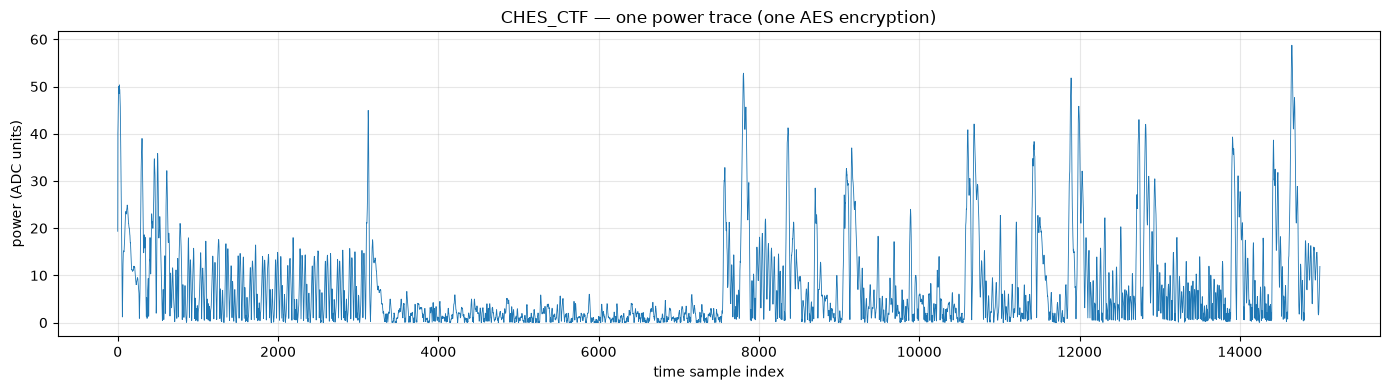

In [5]:
ds = dict(DATASETS)["CHES_CTF"]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ds.x_profiling[0], lw=0.6)
ax.set_title("CHES_CTF — one power trace (one AES encryption)")
ax.set_xlabel("time sample index")
ax.set_ylabel("power (ADC units)")
ax.grid(alpha=0.3)
fig.tight_layout()

fig.savefig(out / "02_single_trace.png", dpi=150)
print("saved:", out / "02_single_trace.png")
plt.show()

Each of the 15,000 points is one instantaneous power measurement. Nothing in
this shape tells a human where the key is — the leakage is statistical and
only shows up across *many* traces. That is what the next sections are for.

## 4. What does a trace look like across datasets?

Overlaying a handful of traces per dataset shows how different the
measurement campaigns are: trace lengths differ by an order of magnitude
(1,400 to 15,000 samples), and so do the shapes — compare the short traces
of ESHARD with the long, spiky traces of CHES_CTF.

Within one dataset, traces differ because each was recorded with a different
plaintext (and therefore different internal values). That variation is what
the attack exploits.

saved: /home/qwertylab/projects/thesis/proyecto-dirigido/feature_emergence/outputs/figures/02_traces_overview.png


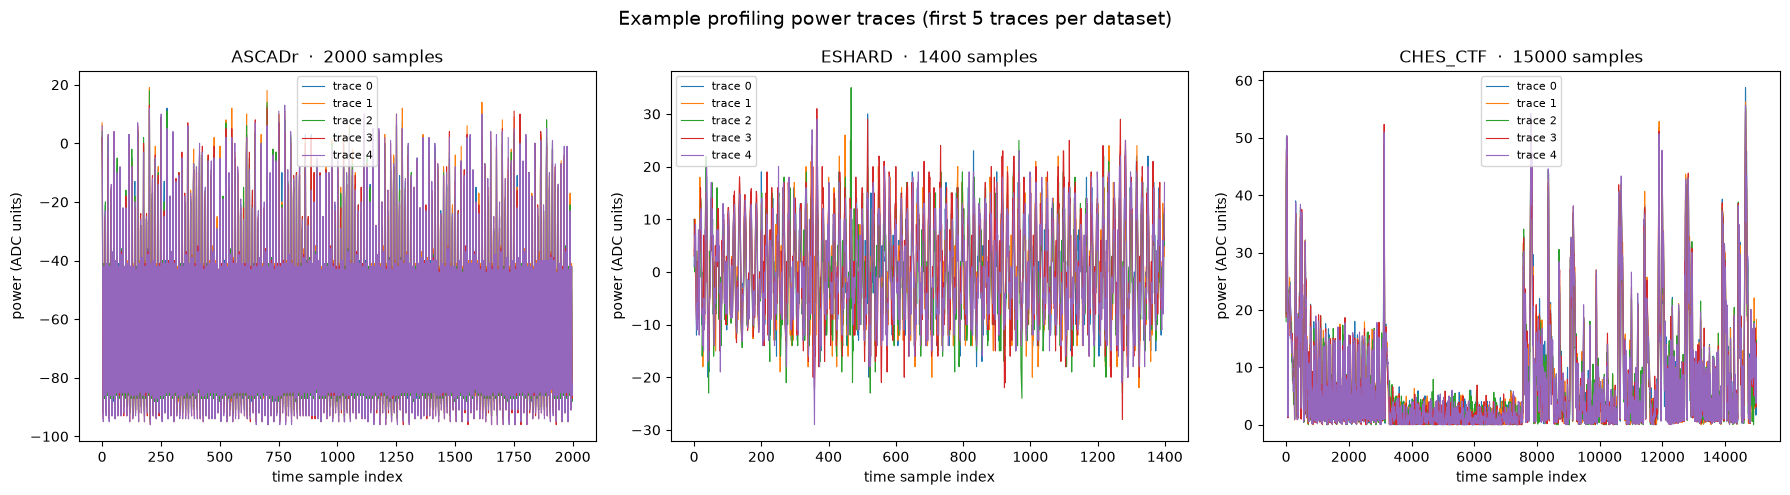

In [6]:
N_TRACES = 5  # traces to overlay per dataset

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, ds) in zip(axes, DATASETS):
    for i in range(N_TRACES):
        ax.plot(ds.x_profiling[i], lw=0.8, label=f"trace {i}")
    ax.set_title(f"{name}  ·  {ds.x_profiling.shape[1]} samples")
    ax.set_xlabel("time sample index")
    ax.set_ylabel("power (ADC units)")
    ax.legend(fontsize=8)

fig.suptitle("Example profiling power traces (first 5 traces per dataset)", fontsize=14)
fig.tight_layout()

fig.savefig(out / "02_traces_overview.png", dpi=150)
print("saved:", out / "02_traces_overview.png")
plt.show()

## 5. Scale and noise: dataset statistics

Before any statistics on leakage, a numerical profile: shape, dtype, and the
basic statistics of the traces. Two details worth noticing:

- ASCADr traces are stored as `int8` (raw ADC codes) while CHES_CTF uses
  `float16` — scale and resolution differ by orders of magnitude.
- The per-trace standard deviation is a rough noise floor: it tells us how
  much of the signal is *not* systematic.

These differences are why models scale their inputs before training.

In [7]:
def trace_stats(x):
    # cast to float32: CHES_CTF traces are float16 and global sums overflow
    x = x.astype(np.float32)
    per_trace_std = x.std(axis=1)
    return (
        x.shape,
        str(x.dtype),
        round(float(x.mean()), 3),
        round(float(x.std()), 3),
        float(x.min()),
        float(x.max()),
        round(float(per_trace_std.mean()), 3),
    )

rows = [("dataset", "shape", "dtype", "mean", "std", "min", "max", "mean(trace std)")]
for name, ds in DATASETS:
    rows.append((name,) + trace_stats(ds.x_profiling))

for row in rows:
    print(" | ".join(str(c) for c in row))

dataset | shape | dtype | mean | std | min | max | mean(trace std)
ASCADr | (20000, 2000) | float32 | -62.965 | 25.851 | -98.0 | 25.0 | 25.848
ESHARD | (20000, 1400) | float32 | -0.029 | 9.271 | -48.0 | 53.0 | 9.255
CHES_CTF | (30000, 15000) | float32 | 6.779 | 8.477 | 0.0 | 115.75 | 8.39


saved: /home/qwertylab/projects/thesis/proyecto-dirigido/feature_emergence/outputs/figures/02_stats_table.png


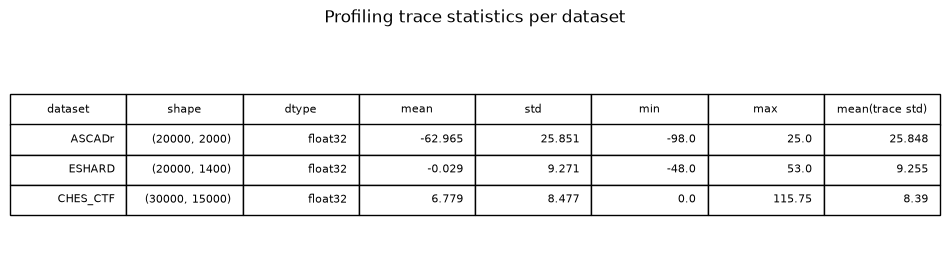

In [8]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis("off")
tbl = ax.table(cellText=rows[1:], colLabels=rows[0], loc="center")
tbl.set_fontsize(11)
tbl.scale(1, 1.8)
ax.set_title("Profiling trace statistics per dataset", pad=12)

fig.savefig(out / "02_stats_table.png", dpi=150, bbox_inches="tight")
print("saved:", out / "02_stats_table.png")
plt.show()

## 6. Where does the key leak? — the SNR

The standard exploration tool in side-channel analysis is the
**Signal-to-Noise Ratio**. For each time sample `t`, we group the profiling
traces by their leakage label and compute:

```
SNR(t) = variance(means of each group) / mean(variances inside each group)
```

A high SNR at sample `t` means the power at that instant varies more
*between* different intermediate values than *within* the same value: that
sample leaks information about the target.

How to read the curves:

- **Tall, narrow peaks**: leakage concentrated at a few clock cycles —
  typical of software AES, where operations run one byte at a time.
- **Low, flat profiles**: leakage spread thin or suppressed — masking pushes
  the peaks down, because the intermediate values are randomized by the
  masks.

The SNR is the baseline against which the feature-emergence analysis later
compares what a trained network actually learns on its own.

/home/qwertylab/projects/thesis/proyecto-dirigido/feature_emergence/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:201: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


/home/qwertylab/projects/thesis/proyecto-dirigido/feature_emergence/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:168: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)


saved: /home/qwertylab/projects/thesis/proyecto-dirigido/feature_emergence/outputs/figures/02_snr_curves.png


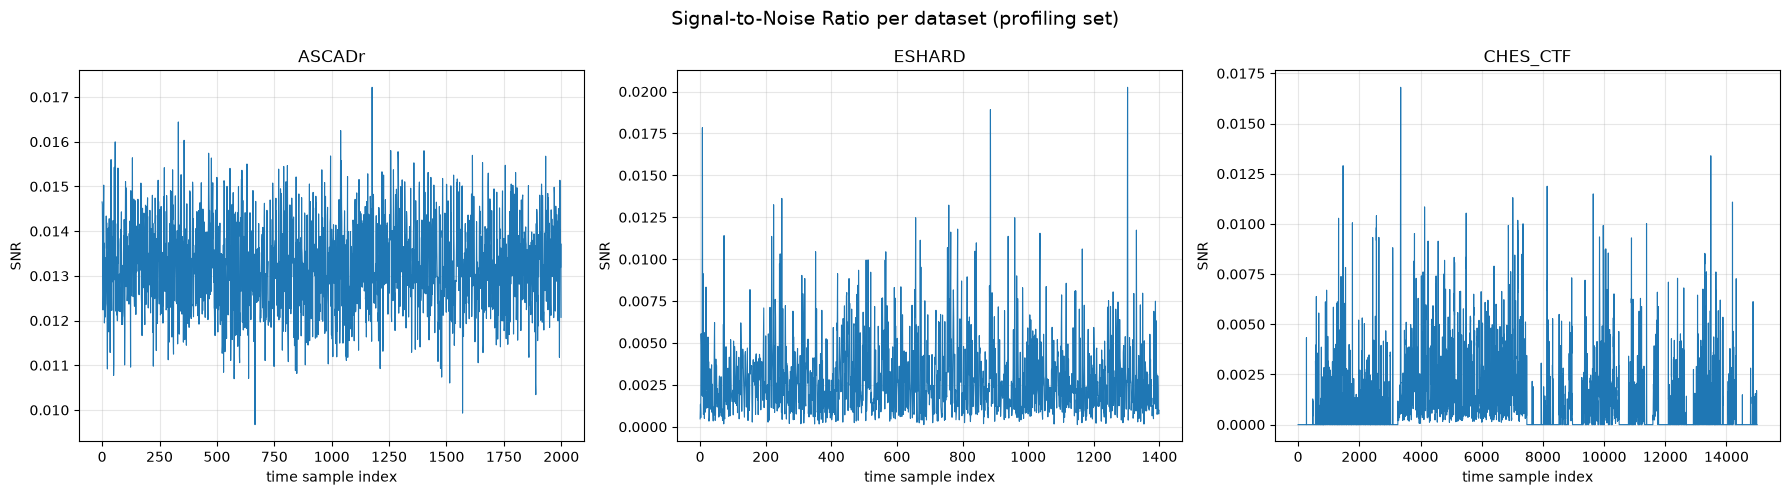

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, ds) in zip(axes, DATASETS):
    snr = snr_fast(ds.x_profiling, ds.profiling_labels)
    ax.plot(snr, lw=0.8)
    ax.set_title(f"{name}")
    ax.set_xlabel("time sample index")
    ax.set_ylabel("SNR")
    ax.grid(alpha=0.3)

fig.suptitle("Signal-to-Noise Ratio per dataset (profiling set)", fontsize=14)
fig.tight_layout()

fig.savefig(out / "02_snr_curves.png", dpi=150)
print("saved:", out / "02_snr_curves.png")
plt.show()

## Takeaways

- An `.h5` dataset is just two paired arrays: power traces, and the
  cryptographic values that produced them.
- The three datasets differ in trace length, scale, and noise — an
  observation that holds for one does not automatically transfer.
- The leakage of the target intermediate is concentrated in identifiable
  time samples, and masking visibly flattens it.
- These SNR curves mark *where* an analyst would look for the key — the
  reference for checking whether a network looks in the same place.